In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline


In [3]:
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv(

    "SMSSpamCollection",

    sep="\t",

    header=None,

    names=["label", "message"]

)

In [6]:
print("="*60)
print("First 5 Records")
print("="*60)

print(df.head())

print("\n")

print("="*60)
print("Last 5 Records")
print("="*60)

print(df.tail())

print("\n")

print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Column Names")
print("="*60)

print(df.columns)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print("\n")

print("="*60)
print("Data Types")
print("="*60)

print(df.dtypes)


First 5 Records
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


Last 5 Records
     label                                            message
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham               Will ü b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any other s...
5570   ham  The guy did some bitching but I acted like i'd...
5571   ham                         Rofl. Its true to its name


Dataset Shape
(5572, 2)


Column Names
Index(['label', 'message'], dtype='str')


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  -

In [7]:
print("\n")

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())



Missing Values
label      0
message    0
dtype: int64


In [8]:
print("\n")

print("="*60)
print("Duplicate Messages")
print("="*60)

print(df.duplicated().sum())



Duplicate Messages
403


In [9]:
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates")

print(df.shape)


Dataset Shape After Removing Duplicates
(5169, 2)




Spam vs Ham
label
ham     4516
spam     653
Name: count, dtype: int64


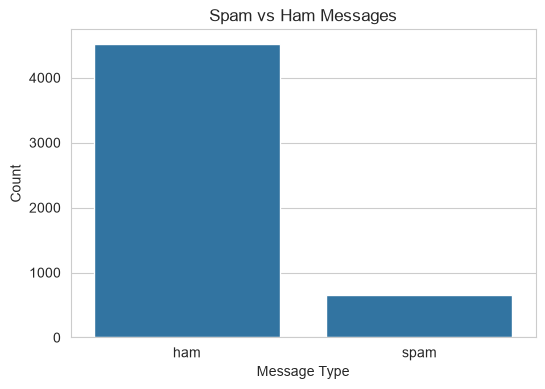

In [10]:
print("\n")

print("="*60)
print("Spam vs Ham")
print("="*60)

print(df["label"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(

    data=df,

    x="label"

)

plt.title("Spam vs Ham Messages")

plt.xlabel("Message Type")

plt.ylabel("Count")

plt.show()


In [11]:
df["label"] = df["label"].map({

    "ham":0,

    "spam":1

})

print("\n")

print("="*60)
print("Encoded Labels")
print("="*60)

print(df.head())



Encoded Labels
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [12]:
df["Character_Count"] = df["message"].apply(len)

In [13]:
df["Word_Count"] = df["message"].apply(

    lambda x: len(x.split())

)

In [14]:
df["Sentence_Count"] = df["message"].apply(

    lambda x: x.count(".") +

              x.count("!") +

              x.count("?") + 1

)

In [15]:
print("\n")

print("="*60)
print("Dataset with New Features")
print("="*60)

print(df.head())



Dataset with New Features
   label                                            message  Character_Count  \
0      0  Go until jurong point, crazy.. Available only ...              111   
1      0                      Ok lar... Joking wif u oni...               29   
2      1  Free entry in 2 a wkly comp to win FA Cup fina...              155   
3      0  U dun say so early hor... U c already then say...               49   
4      0  Nah I don't think he goes to usf, he lives aro...               61   

   Word_Count  Sentence_Count  
0          20               9  
1           6               7  
2          28               2  
3          11               7  
4          13               1  


In [16]:
print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)

print(

    df[[

        "Character_Count",

        "Word_Count",

        "Sentence_Count"

    ]].describe()

)




Statistical Summary
       Character_Count   Word_Count  Sentence_Count
count      5169.000000  5169.000000     5169.000000
mean         79.344554    15.439930        3.491004
std          58.437457    11.117073        2.719676
min           2.000000     1.000000        1.000000
25%          36.000000     7.000000        2.000000
50%          61.000000    12.000000        3.000000
75%         119.000000    22.000000        4.000000
max         910.000000   171.000000       43.000000


In [17]:
print("\n")

print("="*60)
print("Grouped Statistics")
print("="*60)

print(

    df.groupby(

        "label"

    )[

        [

            "Character_Count",

            "Word_Count",

            "Sentence_Count"

        ]

    ].mean()

)




Grouped Statistics
       Character_Count  Word_Count  Sentence_Count
label                                             
0            70.905890   14.239814        3.416519
1           137.704441   23.739663        4.006126


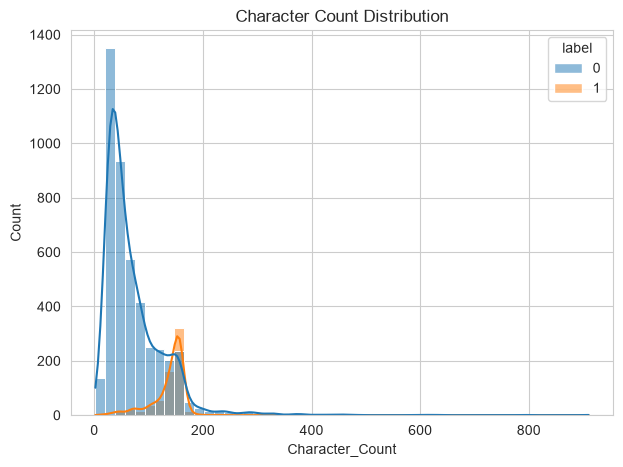

In [18]:
plt.figure(figsize=(7,5))

sns.histplot(

    data=df,

    x="Character_Count",

    hue="label",

    bins=50,

    kde=True

)

plt.title("Character Count Distribution")

plt.show()

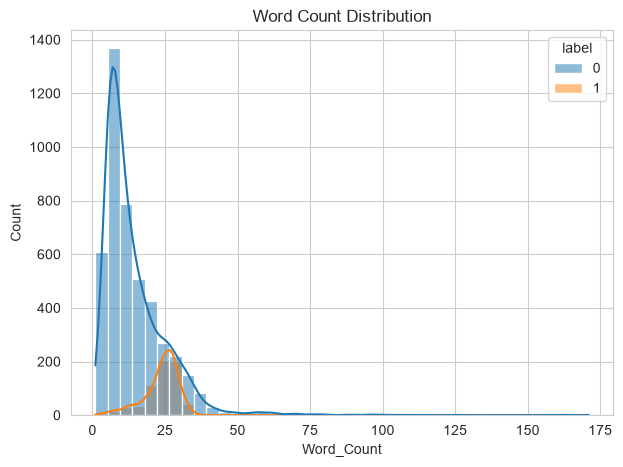

In [19]:
plt.figure(figsize=(7,5))

sns.histplot(

    data=df,

    x="Word_Count",

    hue="label",

    bins=40,

    kde=True

)

plt.title("Word Count Distribution")

plt.show()


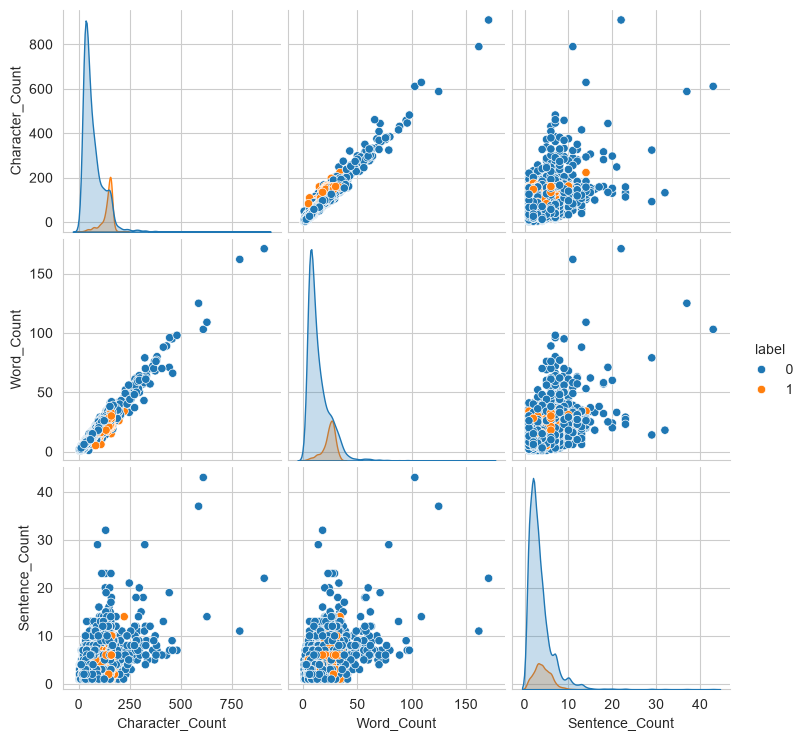

In [20]:
sns.pairplot(

    df[[

        "Character_Count",

        "Word_Count",

        "Sentence_Count",

        "label"

    ]],

    hue="label"

)

plt.show()

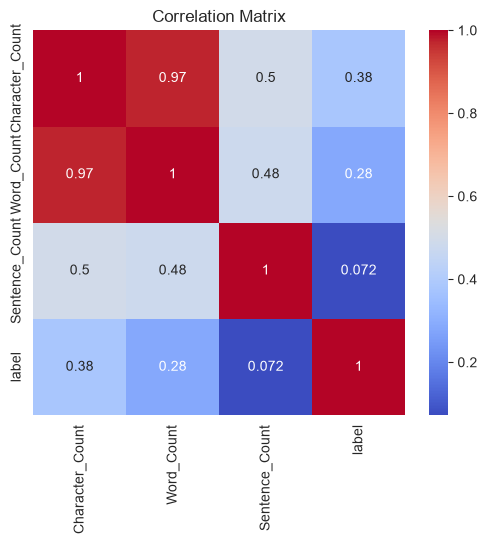

In [21]:
plt.figure(figsize=(6,5))

sns.heatmap(

    df[[

        "Character_Count",

        "Word_Count",

        "Sentence_Count",

        "label"

    ]].corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation Matrix")

plt.show()


In [22]:
X = df["message"]

In [23]:
y = df["label"]

print("\n")

print("="*60)
print("Sample Messages")
print("="*60)

print(X.head())

print("\n")

print("="*60)
print("Target Labels")
print("="*60)

print(y.head())

print("\n")

print("Input Shape :", X.shape)

print("Target Shape:", y.shape)



Sample Messages
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: str


Target Labels
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


Input Shape : (5169,)
Target Shape: (5169,)


In [36]:
import sys
!{sys.executable} -m pip install nltk
import nltk
nltk.data.path.append(r"C:\Users\reddy\AppData\Roaming\nltk_data")
import string
import re

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\reddy\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [31]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\reddy\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reddy\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [32]:
stemmer = PorterStemmer()

In [46]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

# Load stopwords and stemmer once (outside the function for efficiency)
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize text
    words = word_tokenize(text)

    # Remove stop words
    words = [word for word in words if word not in stop_words]

    # Apply stemming
    words = [stemmer.stem(word) for word in words]

    # Join words back into a sentence
    return " ".join(words)


In [50]:
df["processed_message"] = df["message"].apply(

    preprocess_text

)

print("="*70)
print("Original vs Processed Messages")
print("="*70)

comparison = pd.DataFrame({

    "Original": df["message"].head(),

    "Processed": df["processed_message"].head()

})

print(comparison)


Original vs Processed Messages
                                            Original  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                           Processed  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live around though  


In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(

    df["processed_message"]

)

y = df["label"]

print("\n")

print("="*70)
print("TF-IDF Matrix Shape")
print("="*70)

print(X.shape)



TF-IDF Matrix Shape
(5169, 7154)


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\n")

print("="*70)
print("Training Shape")
print("="*70)

print(X_train.shape)

print(y_train.shape)

print("\n")

print("="*70)
print("Testing Shape")
print("="*70)

print(X_test.shape)

print(y_test.shape)




Training Shape
(4135, 7154)
(4135,)


Testing Shape
(1034, 7154)
(1034,)


In [53]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(

    X_train,

    y_train

)

print("\nModel Training Completed Successfully!")


Model Training Completed Successfully!


In [54]:
y_pred = model.predict(

    X_test

)

In [55]:
y_prob = model.predict_proba(

    X_test

)

print("\n")

print("="*70)
print("Predicted Labels")
print("="*70)

print(y_pred[:10])

print("\n")

print("="*70)
print("Prediction Probabilities")
print("="*70)

print(y_prob[:10])




Predicted Labels
[0 0 0 0 0 0 0 0 0 0]


Prediction Probabilities
[[9.99700752e-01 2.99248483e-04]
 [9.81523051e-01 1.84769487e-02]
 [9.98054972e-01 1.94502848e-03]
 [9.92114668e-01 7.88533190e-03]
 [9.88208066e-01 1.17919337e-02]
 [9.85920047e-01 1.40799532e-02]
 [9.93329839e-01 6.67016123e-03]
 [9.95782578e-01 4.21742206e-03]
 [9.81800921e-01 1.81990789e-02]
 [9.57399274e-01 4.26007256e-02]]


In [56]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score

)

accuracy = accuracy_score(

    y_test,

    y_pred

)

precision = precision_score(

    y_test,

    y_pred

)

recall = recall_score(

    y_test,

    y_pred

)

f1 = f1_score(

    y_test,

    y_pred

)

print("\n")

print("="*70)
print("Model Performance")
print("="*70)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")




Model Performance
Accuracy  : 0.9662
Precision : 0.9898
Recall    : 0.7405
F1 Score  : 0.8472


In [57]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([

    ("tfidf", TfidfVectorizer()),

    ("model", MultinomialNB())

])

cv_scores = cross_val_score(

    pipeline,

    df["processed_message"],

    y,

    cv=5,

    scoring="accuracy"

)

print("\n")

print("="*70)
print("Cross Validation")
print("="*70)

print(cv_scores)

print("\nAverage Accuracy")

print(cv_scores.mean())




Cross Validation
[0.96905222 0.9516441  0.95454545 0.96034816 0.95450145]

Average Accuracy
0.9580182788108476


In [58]:
feature_names = tfidf.get_feature_names_out()

spam_scores = model.feature_log_prob_[1]

top_words = pd.DataFrame({

    "Word": feature_names,

    "Importance": spam_scores

})

top_words = top_words.sort_values(

    by="Importance",

    ascending=False

)

print("\n")

print("="*70)
print("Top 20 Spam Words")
print("="*70)

print(top_words.head(20))




Top 20 Spam Words
         Word  Importance
843      call   -5.402176
2178     free   -5.825823
3830    mobil   -6.112884
6400      txt   -6.140176
6075     text   -6.171971
1070    claim   -6.214973
4769    prize   -6.237543
5034    repli   -6.264712
6511       ur   -6.289014
5791     stop   -6.307397
4047      new   -6.531024
6514   urgent   -6.560538
5329   servic   -6.562944
1211  contact   -6.612786
4589    pleas   -6.646625
921      cash   -6.687360
4113    nokia   -6.714662
6829      win   -6.718685
420     award   -6.730521
6268     tone   -6.741153


Confusion Matrix
[[902   1]
 [ 34  97]]


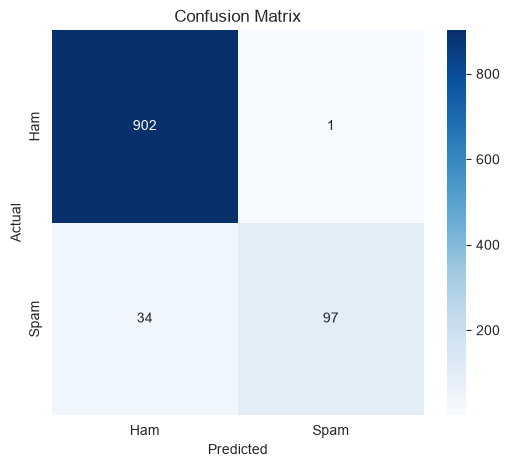

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    y_pred

)

print("="*70)
print("Confusion Matrix")
print("="*70)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Ham","Spam"],

    yticklabels=["Ham","Spam"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [60]:
from sklearn.metrics import classification_report

print("\n")

print("="*70)
print("Classification Report")
print("="*70)

print(

    classification_report(

        y_test,

        y_pred,

        target_names=["Ham","Spam"]

    )

)



Classification Report
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



In [61]:
from sklearn.metrics import (

    roc_curve,

    roc_auc_score

)


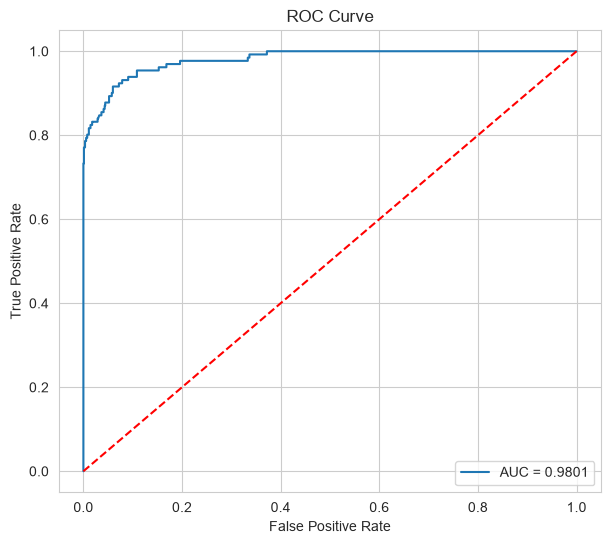



ROC AUC Score
0.9801256202818425


In [62]:
spam_probability = y_prob[:,1]

fpr, tpr, thresholds = roc_curve(

    y_test,

    spam_probability

)

auc_score = roc_auc_score(

    y_test,

    spam_probability

)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc_score:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="red"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("\n")

print("="*70)
print("ROC AUC Score")
print("="*70)

print(auc_score)

In [63]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

print("\n")

print("="*70)
print("Sample Predictions")
print("="*70)

print(comparison.head(20))



Sample Predictions
    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          0
18       0          0
19       0          0


In [64]:
new_sms = [

    "Congratulations! You have won a FREE iPhone. Call now to claim your prize."

]


In [65]:
processed_sms = [

    preprocess_text(message)

    for message in new_sms

]

In [66]:
sms_vector = tfidf.transform(

    processed_sms

)

In [67]:
prediction = model.predict(

    sms_vector

)

In [68]:
prediction_probability = model.predict_proba(

    sms_vector

)

print("\n")

print("="*70)
print("Prediction for New SMS")
print("="*70)

print("Message")

print(new_sms[0])

print("\nPredicted Class :", prediction[0])

if prediction[0] == 0:

    print("Result : HAM (Legitimate Message)")

else:

    print("Result : SPAM Message")

print("\nPrediction Probability")

print(prediction_probability)




Prediction for New SMS
Message
Congratulations! You have won a FREE iPhone. Call now to claim your prize.

Predicted Class : 1
Result : SPAM Message

Prediction Probability
[[0.1123938 0.8876062]]


In [69]:
from joblib import dump

dump(

    model,

    "spam_detection_model.joblib"

)

dump(

    tfidf,

    "tfidf_vectorizer.joblib"

)

print("\nModel Saved Successfully!")



Model Saved Successfully!


In [70]:
from joblib import load

loaded_model = load(

    "spam_detection_model.joblib"

)

loaded_vectorizer = load(

    "tfidf_vectorizer.joblib"

)

print("Saved Model Loaded Successfully!")


Saved Model Loaded Successfully!


In [71]:
loaded_vector = loaded_vectorizer.transform(

    processed_sms

)

loaded_prediction = loaded_model.predict(

    loaded_vector

)

print("\nPrediction Using Loaded Model")

print(loaded_prediction)


Prediction Using Loaded Model
[1]


In [72]:
sample_messages = [

    "Hey, are you free this evening?",

    "URGENT! Claim your FREE reward now.",

    "Meeting has been postponed to tomorrow.",

    "You have won $1000 cash. Click the link now!"

]

print("\n")

print("="*70)
print("Multiple SMS Predictions")
print("="*70)

for sms in sample_messages:

    processed = preprocess_text(sms)

    vector = loaded_vectorizer.transform([processed])

    result = loaded_model.predict(vector)[0]

    probability = loaded_model.predict_proba(vector)[0]

    print(f"\nMessage : {sms}")

    if result == 0:

        print("Prediction : HAM")

    else:

        print("Prediction : SPAM")

    print(f"Probability : {probability}")




Multiple SMS Predictions

Message : Hey, are you free this evening?
Prediction : HAM
Probability : [0.96651386 0.03348614]

Message : URGENT! Claim your FREE reward now.
Prediction : SPAM
Probability : [0.10269385 0.89730615]

Message : Meeting has been postponed to tomorrow.
Prediction : HAM
Probability : [0.95020008 0.04979992]

Message : You have won $1000 cash. Click the link now!
Prediction : HAM
Probability : [0.55690936 0.44309064]


In [73]:
print("\n")

print("="*70)
print("SMS Spam Detection using Multinomial Naive Bayes")
print("="*70)

print(f"Total Messages           : {len(df)}")

print(f"Ham Messages             : {(df['label']==0).sum()}")

print(f"Spam Messages            : {(df['label']==1).sum()}")

print(f"\nTraining Samples        : {X_train.shape[0]}")

print(f"Testing Samples         : {X_test.shape[0]}")

print(f"TF-IDF Features         : {X_train.shape[1]}")

print(f"\nAccuracy               : {accuracy:.4f}")

print(f"Precision              : {precision:.4f}")

print(f"Recall                 : {recall:.4f}")

print(f"F1 Score               : {f1:.4f}")

print(f"ROC AUC Score          : {auc_score:.4f}")

print(f"Cross Validation       : {cv_scores.mean():.4f}")

print("\nModel Status : Ready for Deployment")

print("="*70)

print("\nProject Completed Successfully!")



SMS Spam Detection using Multinomial Naive Bayes
Total Messages           : 5169
Ham Messages             : 4516
Spam Messages            : 653

Training Samples        : 4135
Testing Samples         : 1034
TF-IDF Features         : 7154

Accuracy               : 0.9662
Precision              : 0.9898
Recall                 : 0.7405
F1 Score               : 0.8472
ROC AUC Score          : 0.9801
Cross Validation       : 0.9580

Model Status : Ready for Deployment

Project Completed Successfully!
